<a href="https://colab.research.google.com/github/ga4gh/analytics-dashboard/blob/plenary-proof-of-concept/notebooks/Analytics_Dashboard_Github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub Analytics Dashboard

This notebook provides a proof of concept for a comprehensive analytics dashboard for exploring GitHub repositories related to GA4GH products and initiatives.


### What This Notebook Does

This notebook automatically:
1. **Fetches repositories** from GitHub within the GA4GH organization
2. **Analyzes the data** to show trends, statistics, and insights
3. **Creates interactive visualizations** to graphically present trends in the data

## How to Run This Notebook

1. **Click "Run All" in your Jupyter environment** - Everything will run automatically
2. **Wait for results** - The notebook will fetch data and create visualizations
3. **Scroll through the results** - Each section provides different insights

## What You Can Customize

### Advanced Changes
- Requires knowledge of Plotly and Dash libraries
- Can modify visualization types, styling, and data presented
- Replace Y and/or X axis with values obtained from json stored in the ```GA4GH_repos``` variable

## What You'll See

1. **User Interaction** - A look at user interactions such as watching, forking, or subscribing to a repository
2. **Yearly Productivity** - A chart of repositories created every year since the inception of GA4GH
3. **Open Issues** - A graph comparing the repositories with the most open issues
4. **Activity Status** - A chart displaying the amount of archived, forked, or active
   
## Important Notes

- **Processing time** - Initial run may take 2-3 minutes
- **Internet required** - Fetches data from API set up by the tech team
- **No data storage** - Results are temporary unless you save them

## Troubleshooting

**If visualizations don't appear:**
1. Ensure you have the required libraries installed
2. Try refreshing your browser
3. Check that JavaScript is enabled

**If results seem incomplete:**  
***Note: This is not a complete dataset. This is a POC and will be more complete in the future***
1. Try running individual sections instead of all at once


### Libraries Used in This Notebook

**dash** → Used to build interactive dashboard components such as graphs, layouts, and user inputs directly inside the notebook.

**requests** → Connects to external APIs (GitHub API in this case) and retrieves data in JSON format.

**pandas** → Helps convert API responses into DataFrames for easy filtering, analysis, and visualization.

**json** → Used for handling and inspecting raw JSON responses returned by the GitHub API.

**typing (List, Optional, Dict, Any)** → Adds optional type hints to improve code readability and maintainability.

**plotly.express** → Creates interactive charts (bar, line, pie, scatter) quickly and easily.

In [10]:
# Make sure Dash is installed
!pip install dash


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [6]:
# Some of the imports required to use the notebook
import requests
import json
import dash
from typing import List, Optional, Dict, Any
from dash import Dash, dcc, html, Input, Output, callback
import plotly.express as px
import pandas as pd


## Configurations & API Setup
---
**Explanation:**
- ```GH_BASE_URL```: is the main endpoint we will be using for this notebook. It will return a github repo by name as it is stored in the DB
- ```get_repos(GH_BASE_URL, repos_list)```: This function will retrieve all the repos under the "ga4gh" org from the DB
  1. Makes a GET request to the specified endpoint.  
  2. Raises an error if the request fails.  
  3. Returns the response as JSON for further processing.

---

**Data Exploration:**  
- You can test this by running, for example:  
  ```python
  get_repos(GH_BASE_URL, repos_list)

In [11]:
'''
Setup functions to fetch the data that we will be using
'''
# Endpoint retrieving the details of a github that is stored in a DB
GH_BASE_URL = "http://analytics-staging.ga4gh.org:8000/github/name/"

# Endpoints from the Github API where the data is collected from
GH_API_URL = "https://api.github.com"
GH_repos = "https://api.github.com/orgs/ga4gh/repos"

# Function that will take a list of repos and retrieve them from the DB
def get_repos(endpoint: str, list_of_repos: List[str]) -> List[Dict[str, Any]]:

    items: List[Dict[str, Any]] = []
    url = endpoint

    for repo in list_of_repos:
        resp = requests.get(url + repo)
        resp.raise_for_status()
        items.append(resp.json()[0])

    return items

def get_json(endpoint: str, token: Optional[str] = None, per_page: int = 100) -> List[Dict[str, Any]]:

    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"

    params = {"per_page": per_page, "page": 1}
    items: List[Dict[str, Any]] = []
    url = endpoint

    while True:
        resp = requests.get(url, headers=headers, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not isinstance(data, list):
            return data

        items.extend(data)

        if "next" in resp.links:
            url = resp.links["next"]["url"]
            params = None
        else:
            break

    return items

repos_list = ['ga4gh-schemas', 'ga4gh-server', 'compliance', 'dwg-website', 'gastore', 'mme-apis', 'metadata-team', 'g2p-team', 'benchmarking-tools', 'build', 'tool-registry-service-schemas', 'swg-ssig', 'tool-registry-server', 'workflow-execution-server', 'task-execution-server', 'task-execution-schemas', 'workflow-execution-service-schemas', 'ga4gh-consent-policy', 'hgvs-lib', 'tool-registry-validator', 'tool-registry-reference-implementation', 'vrs', 'hackathon2016', 'ga4gh-client', 'ga4gh-common', 'htsget', 'data-repository-service-schemas', 'ga4gh-converters', 'ADA-M', 'wiki', 'vrs-python', 'cloud-interop-testing', 'phenopacket-schema', 'large-scale-genomics-wiki', 'refget-compliance-suite', 'va-spec', 'variant-representation', 'approval-tracker', 'duri', 'refget-client', 'cloud-conformance-testing', 'data-object-service-schemas', 'w3id.org', 'data-security', 'pedigree', 'gh-openapi-docs', 'ga4gh-drs-client', 'refget-cloud', 'htsget-refserver', 'refget-loader', 'cloud-interop-ui', 'ga4gh-copyright-policy', 'TASC', 'standards-schema', 'htsget-compliance', 'ga4gh-registry', 'gatk', 'refget-compliance', 'htsjdk', 'ga4gh-bed', 'fasp-scripts', 'htsget-refserver-utils', 'ga4gh-ci', 'refget', 'reverse-lookup-spec', 'ga4gh-starter-kit-drs', 'vrs-vcf-alignment', 'pedigree-fhir-ig', 'vrsatile', 'ga4gh-starter-kit-docs', 'ga4gh-starter-kit-common', 'ga4gh-starter-kit-passport-broker', 'pedigree_family_history_terminology', 'ga4gh-starter-kit-wes', 'ga4gh-starter-kit', 'ga4gh-starter-kit-ui', 'machine-readable-consent-guidance', 'pedigree-tools', 'vrs-protobuf', 'ga4gh-starter-kit-utils', 'vrsatile-pydantic', 'ga4gh-testbed-lib', 'ga4gh-starter-kit-refget', 'ga4gh-testbed-ui', 'pedigree-validator', 'gks-metaschema', 'future-of-vcf', 'ga4gh-starter-kit-data-connect', 'cloud-best-practices', 'schema-registry-api', 'schema-registry-ui', 'schema-registry', 'tech-team', 'ga4gh-testbed-api', 'vrs-hackathons', 'Get-Started-with-GA4GH-APIs', 'ga4gh-starter-kit-passport-ui', 'vrs-phenopackets', 'cohort-rep-hackathon', 'product-process', 'openapi-test-runner', 'drs-compliance-suite', 'vrs-clojure', 'fasp-clients', 'sa-spec', 'gk-pilot', 'ga4gh-starter-kit-beacon', 'quality-control-wgs', 'Strategic-Refresh', 'drs-test-a-thon', 'experiments-metadata', 'ga4gh-pgx', 'compliance-tests-ga4gh-tes', 'ga4gh-crypt4gh', 'compliance-tests-ga4gh-wes', 'ga4gh-doi', 'gks-core', 'cat-vrs', 'compliance-tests-ga4gh-service-registry', 'ga4gh-testbed-api-aws-stack', 'gks2clinvar', 'human-pangenome-project', 'gks-validator', 'gks-portal', 'cat-vrs-python', 'va-spec-python', 'Website-flowcharts', 'gks-starter-repo']

## A Look at User Interactions with GA4GH Repos

Some of the main ways a user can show interest in a repository on github is to watch, fork, or subscribe to a repo.

For those not familiar with Github terminology:
- **Watchers**: Are users who have selected to recieve notifications about general activity in a repository
- **Subscribers**: Are users who want to know about specific issues within a repo such as open issues or pull request
- **Forks**: Are the ultimate form of interaction as it means a user loves the repo so much they have chosen to create their own personal copy so they can modify the code however they like

Assuming the sum of these 3 values is a rough indicator of the level of interest in a given repo, the cell below will generate a stacked bar graph with watchers + subscribers + forks.

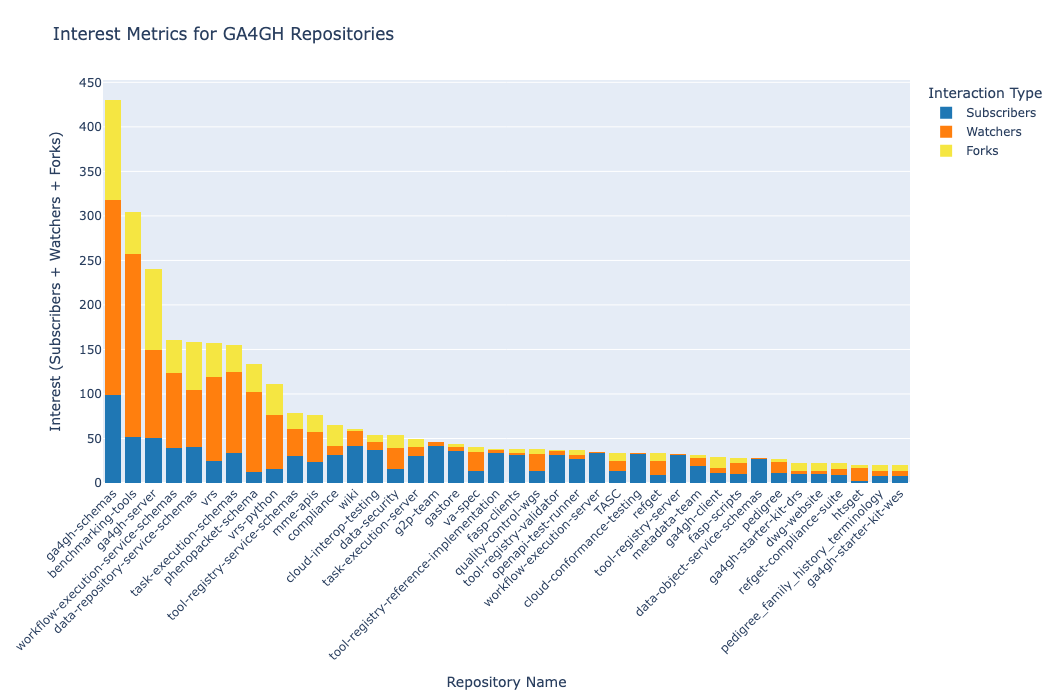

In [12]:


GA4GH_repos = get_repos(GH_BASE_URL, repos_list)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_subscribers = [repo['subscribers_count'] for repo in GA4GH_repos]
GA4GH_repos_watchers = [repo['watchers_count'] for repo in GA4GH_repos]
GA4GH_repos_forks = [repo['forks_count'] for repo in GA4GH_repos]

df = pd.DataFrame({
    "Repo": GA4GH_repos_names,
    "Subscribers": GA4GH_repos_subscribers,
    "Forks": GA4GH_repos_forks,
    "Watchers": GA4GH_repos_watchers
})

df["total"] = df["Subscribers"] + df["Watchers"] + df["Forks"]
df = df.sort_values("total", ascending=False).reset_index(drop=True)

df = df.head(40)

fig1 = px.bar(
    df,
    x="Repo",
    y=["Subscribers", "Watchers", "Forks"],
    labels={"value": "Count", "repo": "Repository"},
    title="Interest Metrics for GA4GH Repositories",
    color_discrete_sequence=["#1f77b4", "#ff7f0e", "#f5e642"],
)

fig1.update_layout(
    barmode="stack",
    xaxis_tickangle=-45,
    margin=dict(l=40, r=20, t=80, b=150),
    xaxis_title="Repository Name",
    yaxis_title="Interest (Subscribers + Watchers + Forks)",
    legend_title_text="Interaction Type",
    height = 700
)
fig1.update_traces(marker_line_width=0)

## Tracking Yearly Productivity Within GA4GH
A rough way to measure how productive GA4GH was in any given year is through the amount of new repos that are created in that year. Using the data we can obtain from the Github API, we can show trends on how many new repos are created since the inception of GA4GH.

Mouse over the node to see which repos were created during that year.

In [13]:
GA4GH_repos = get_json(GH_repos)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_created_at = [repo['created_at'] for repo in GA4GH_repos]

df = pd.DataFrame({"repo": GA4GH_repos_names, "created_at": pd.to_datetime(GA4GH_repos_created_at)})

df["year"] = df["created_at"].dt.year
grouped = df.groupby("year").agg({"repo": list})
grouped["count"] = grouped["repo"].apply(len)

grouped["repos_str"] = grouped["repo"].apply(lambda repos: "<br>".join(repos))

grouped = grouped.reset_index().sort_values("year")

fig2 = px.line(
    grouped,
    x="year",
    y="count",
    markers=True,
    title="Number of GA4GH Repositories Created per Year",
    labels={"year": "Year", "count": "Number of repositories"},
)

fig2.data[0].customdata = grouped[["repos_str"]].to_numpy()

fig2.update_traces(
    hovertemplate="Repos:<br>%{customdata[0]}<extra></extra>",
    marker=dict(size=8),
)

fig2.update_layout(
    xaxis_title="Year",
    yaxis_title="New Repositories",
    margin=dict(l=40, r=20, t=70, b=120),
    height=500
)

## Ranking Repos Using Open Issues

One way for users of open source software to speak their mind is to create an open issue in the repo.

**Open issues**: are a way for users to directly request new features or changes within a piece of software that can be addressed and tracked publicly by the developers. This allows for open discussion and encourages users to be directly involved and provide feedback from their perspective.

**Disclaimer:** You may note that that "ga4gh-schemas" as well as a few other repos with high open issues count have been retired.

In [ ]:
GA4GH_repos = get_repos(GH_BASE_URL, repos_list)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_issues = [repo['open_issues_count'] for repo in GA4GH_repos]
GA4GH_repos_is_archived = [repo['is_archived'] for repo in GA4GH_repos]

df = pd.DataFrame({
    "Repo": GA4GH_repos_names,
    "Open_issues": GA4GH_repos_issues,
    "Is_archived": GA4GH_repos_is_archived
})

df["Is_archived"] = df["Is_archived"].fillna(False).astype(bool)

df = df.sort_values("Open_issues", ascending=False).reset_index(drop=True)
df = df.head(20)

fig3 = px.bar(
    df,
    x="Repo",
    y="Open_issues",
    title="Open Issues Across Top 20 GA4GH repositories",
    hover_data=["Open_issues"],
    color="Is_archived",
    color_discrete_map={True: "grey", False: "#1f77b4"},
    category_orders={"Repo": df["Repo"].tolist()}
)

fig3.update_layout(
    xaxis_tickangle=-45,
    margin=dict(l=40, r=20, t=80, b=150),
    xaxis_title="Repository",
    yaxis_title="Open Issues",
    height=700,
    legend_title_text="Archived"
)
fig3.update_traces(marker_line_width=0)

## Status of GA4GH Repos

Speaking of archived repos, we can look at the GA4GH organization to see how many repositories are archived, forked from other organizations, both archived and forked, or developed within the GA4GH org. As GA4GH evolves, some repositories naturally become obsolete, while others may be adopted from another organization within the GA4GH community. These counts help illustrate which repositories in the GA4GH GitHub organization are actively maintained, which have been retired, and which are continuations of work from another organization.

In [ ]:
GA4GH_repos = get_repos(GH_BASE_URL, repos_list)
GA4GH_repos_names = [repo['name'] for repo in GA4GH_repos]
GA4GH_repos_is_archived = [repo["is_archived"] for repo in GA4GH_repos]
GA4GH_repos_is_fork = [repo["is_fork"] for repo in GA4GH_repos]

statuses = []
for name, is_archived, is_fork in zip(GA4GH_repos_names, GA4GH_repos_is_archived, GA4GH_repos_is_fork):
    is_archived = bool(is_archived)
    is_fork = bool(is_fork)
    if is_fork and is_archived:
        statuses.append("Archived & Fork")
    elif is_fork:
        statuses.append("Fork")
    elif is_archived:
        statuses.append("Archived")
    else:
        statuses.append("Active")

df_status = pd.DataFrame({
    "repo": GA4GH_repos_names,
    "status": statuses
})

grouped = df_status.groupby("status")["repo"].apply(list).reset_index(name="repo_list")
grouped["count"] = grouped["repo_list"].apply(len)

def make_hover_list(repolist, max_items=40):
    if not repolist:
        return ""
    if len(repolist) <= max_items:
        return "<br>".join(repolist)
    return "<br>".join(repolist[:max_items]) + f"<br>... (+{len(repolist)-max_items} more)"

grouped["repo_list_html"] = grouped["repo_list"].apply(make_hover_list)

grouped = grouped.sort_values("count", ascending=False).reset_index(drop=True)

color_map = {
    "Fork": "26547c",
    "Archived": "ef476f",
    "Archived & Fork": "#9467bd",
    "Active": "ffd166"
}

fig4 = px.pie(
    grouped,
    names="status",
    values="count",
    hover_data=["repo_list_html"],
    title="Percent of GA4GH Github Repos That Are Forked, Archived, or Active",
    color="status",
    color_discrete_map=color_map
)

fig4.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Count: %{value}<br>"
        "Repos:<br>%{customdata[0]}<extra></extra>"
    ),
    textinfo="percent+label",
    marker_line_width=0
)

fig4.update_layout(
    margin=dict(l=40, r=20, t=80, b=120),
    height=700,
    legend_title_text="Status"
)


## Create All Graphs

Generate all graphs within one cell and if running locally, you can view all graphs in greater detail **[here](http://127.0.0.1:8050/)**

In [ ]:
app = Dash(__name__)
app.layout = html.Div([
    html.Div([
        html.H4("GA4GH repositories — Watchers + Stargazers + Forks"),
        dcc.Graph(id="graph", figure=fig1),
    ]),
    html.Div([
        html.H4("New GA4GH Github Repositories Added Yearly"),
        dcc.Graph(id="hist-year", figure=fig2),
    ]),
    html.Div([
        html.H4("20 GA4GH Repos With Most Open Issues"),
        dcc.Graph(id="open-issues-pie", figure=fig3),
    ])
])

app.run(debug=True)